In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from scipy.stats import linregress

plt.style.use('default')

In [2]:
DB_USER = "postgres"
DB_PASSWORD = "newpassword"
DB_HOST = "localhost"
DB_PORT = "5433"
DB_NAME = "DailyVitals"

connection_string = (
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(connection_string)

# - Load Exercise Data

In [3]:
query = """
SELECT
    e.exercise_session_id,
    p.first_name,
    et.exercise_name,
    e.start_time,
    e.duration_minutes,
    e.calories_expended,
    e.intensity
FROM exercise_session e
JOIN person p
    ON p.person_id = e.person_id
JOIN exercise_type et
    ON et.exercise_type_id = e.exercise_type_id
ORDER BY start_time;
"""

df = pd.read_sql(query, engine)

df.head()

,exercise_session_id,first_name,exercise_name,start_time,duration_minutes,calories_expended,intensity
0,2,Kevin,Shovel Snow,2026-02-26,20.0,166.0,Moderate
1,8,Kevin,Shovel Snow,2026-02-27,15.0,124.0,Moderate
2,10,Kevin,Shovel Snow,2026-02-28,15.0,124.0,Moderate
3,11,Kevin,Stationary Bike,2026-03-01,30.0,248.0,Moderate
4,12,Kevin,Stationary Bike,2026-03-02,30.0,249.0,Moderate


# Basic Statistics

In [4]:
print("Sessions:", len(df))
print()

print("Total Calories Burned:",
      df["calories_expended"].sum())

print("Average Calories Per Session:",
      round(df["calories_expended"].mean(), 1))

print("Maximum Session:",
      df["calories_expended"].max())

print("Minimum Session:",
      df["calories_expended"].min())

Sessions: 105

Total Calories Burned: 39218.0
Average Calories Per Session: 373.5
Maximum Session: 1040.0
Minimum Session: 29.0


# Trend Chart

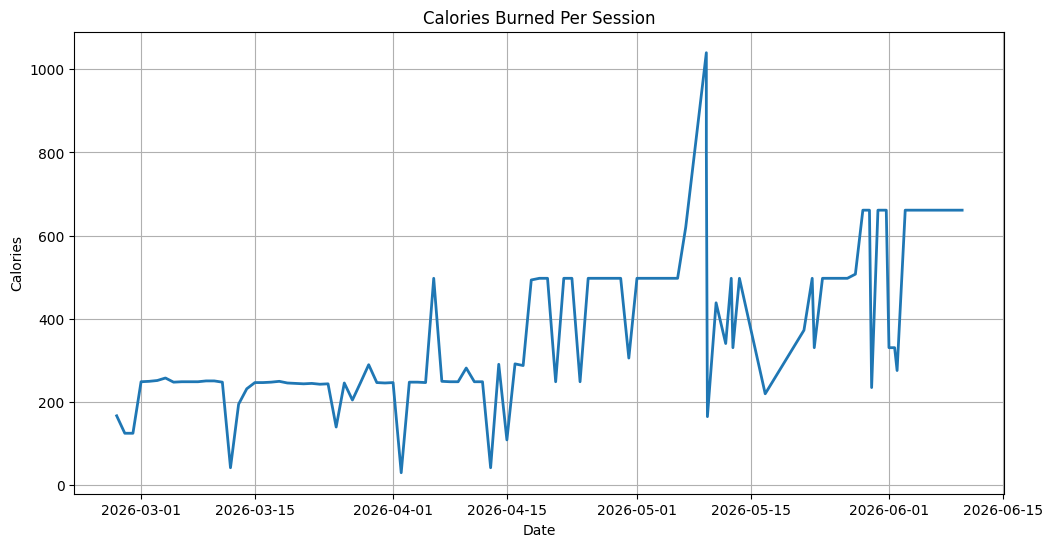

In [5]:
plt.figure(figsize=(12,6))

plt.plot(
    df["start_time"],
    df["calories_expended"],
    linewidth=2
)

plt.title("Calories Burned Per Session")
plt.ylabel("Calories")
plt.xlabel("Date")

plt.grid(True)

plt.show()

# Rolling Average

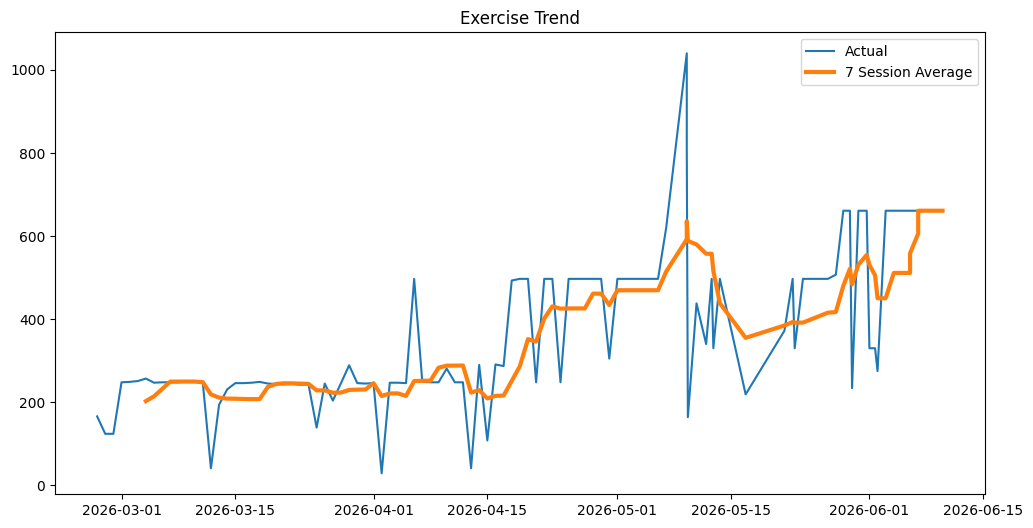

In [6]:
df["rolling_7"] = (
    df["calories_expended"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    df["start_time"],
    df["calories_expended"],
    label="Actual"
)

plt.plot(
    df["start_time"],
    df["rolling_7"],
    linewidth=3,
    label="7 Session Average"
)

plt.legend()

plt.title("Exercise Trend")
plt.show()

# Trend Direction

In [7]:
x = np.arange(len(df))

y = df["calories_expended"]

slope, intercept, r, p, std_err = linregress(x, y)

print("Trend Slope:", round(slope,2))

if slope > 10:
    print("Strong Upward Trend")
elif slope > 2:
    print("Moderate Upward Trend")
elif slope > -2:
    print("Flat Trend")
else:
    print("Declining Trend")

Trend Slope: 4.51
Moderate Upward Trend


# Monthly Summary

In [8]:
df["month"] = pd.to_datetime(
    df["start_time"]
).dt.to_period("M")

monthly = (
    df.groupby("month")
      .agg(
          sessions=("exercise_session_id","count"),
          total_calories=("calories_expended","sum"),
          avg_calories=("calories_expended","mean")
      )
      .reset_index()
)

monthly

,month,sessions,total_calories,avg_calories
0,2026-02,3,414.0,138.000000
1,2026-03,31,7272.0,234.580645
2,2026-04,30,9818.0,327.266667
3,2026-05,27,13508.0,500.296296
4,2026-06,14,8206.0,586.142857


# Monthly Calories Chart

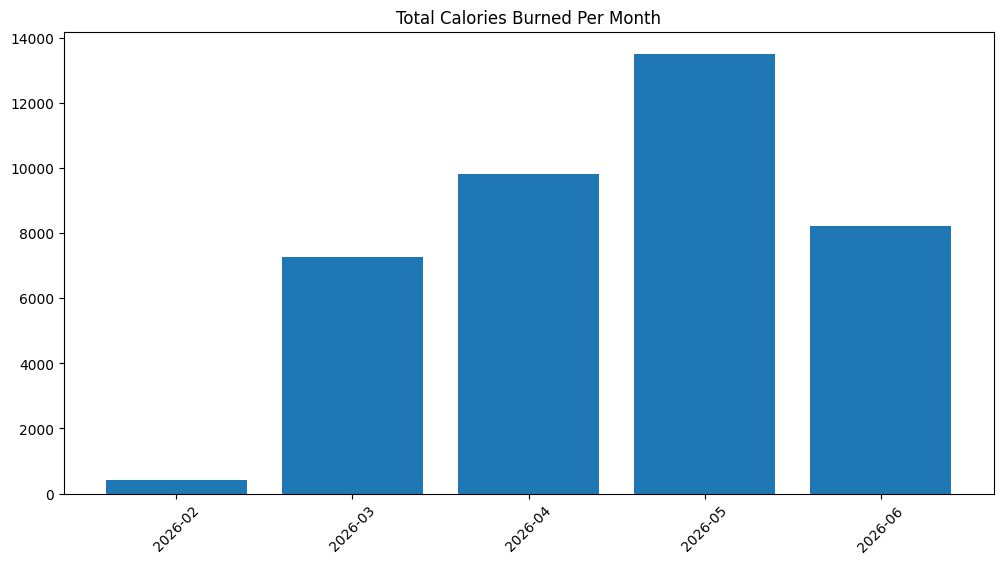

In [9]:
plt.figure(figsize=(12,6))

plt.bar(
    monthly["month"].astype(str),
    monthly["total_calories"]
)

plt.title("Total Calories Burned Per Month")
plt.xticks(rotation=45)

plt.show()

# Consistency Score

In [10]:
std = df["calories_expended"].std()

avg = df["calories_expended"].mean()

cv = std / avg

consistency = max(
    0,
    round(100 - (cv * 100))
)

print("Consistency Score:", consistency)

Consistency Score: 49


# Personal Records

In [11]:
best = df.nlargest(
    5,
    "calories_expended"
)

best[
    [
        "start_time",
        "exercise_name",
        "calories_expended"
    ]
]

,start_time,exercise_name,calories_expended
71,2026-05-09 12:49:12.610771,Painting,1040.0
72,2026-05-09 12:50:59.415824,Painting,803.0
86,2026-05-28 18:55:34.146641,Stationary Bike,661.0
87,2026-05-29 14:25:32.822098,Stationary Bike,661.0
89,2026-05-30 15:26:09.139951,Stationary Bike,661.0


# Summary Generator

In [12]:
latest = df.iloc[-1]

total_minutes = int(df["duration_minutes"].sum())

hours = total_minutes // 60
minutes = total_minutes % 60

summary = f"""
Exercise Summary

Sessions:
{len(df)}

Average Calories:
{df['calories_expended'].mean():.0f}

Latest Session:
{latest['calories_expended']:.0f}

Best Session:
{df['calories_expended'].max():.0f}

Total Calories Burned:
{df['calories_expended'].sum():,.0f}

Total Exercise Time:
{hours} hr {minutes} min
"""

print(summary)


Exercise Summary

Sessions:
105

Average Calories:
374

Latest Session:
661

Best Session:
1040

Total Calories Burned:
39,218

Total Exercise Time:
74 hr 50 min

